# Semana 1

### Lecture 01 - 04/08/2026

Prof. Pedro Henrique de Almeida Konzen.
Avaliação: artigo sobre um problema a ser resolvido com métodos numéricos vistos na disciplina. Apresentar em formato de seminário.
(Escolher o  tema [linkado com a tese] e um tema da disciplina que possa ser relacionado. O professor irá avaliar se é viável ou não.)

In [4]:
# Exercise 1.2.2:

name = input("Digite seu nome: ")
print(f"Hello, {name}!!!")

Hello, Éderson Passos!!!


## Lecture 04 - 13/08/2026

## 1.1 Band Matrix

In [13]:
size_float = 8
# matrix n x n
n = 100_000
print(f"Storage: {n*n*size_float/1024**3} GB")

Storage: 74.50580596923828 GB


In [14]:
# Example 1.1.2: 1D Poisson Equation
import numpy as np
n = 11
h = 1/(n-1)
xx = np.linspace(0, 1, n)
# Matrix
Ab = np.zeros((3,n))
u_diagonal = 1
l_diagonal = 1

def index(i, j):
    return u_diagonal + i - j, j

function = lambda x: np.pi**2*np.sin(np.pi*x)
b = np.zeros(n)

# Build the matrix
Ab[index(0,0)] = 1.0

for i in range(1, n-1):
    Ab[index(i,i)] = 2.0
    Ab[index(i,i-1)] = -1.0
    Ab[index(i,i+1)] = -1.0
    b[i] = function(xx[i])

Ab[index(n-1,n-1)] = 1.0
print(Ab)
print(b)

[[ 0.  0. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [ 1.  2.  2.  2.  2.  2.  2.  2.  2.  2.  1.]
 [-1. -1. -1. -1. -1. -1. -1. -1. -1.  0.  0.]]
[0.         3.04987549 5.80120791 7.98467769 9.38655158 9.8696044
 9.38655158 7.98467769 5.80120791 3.04987549 0.        ]


In [15]:
def solve_tribanded(ab, b):
    a = ab.copy()
    x = b.copy()
    n = b.size
    # eliminação
    for i in range(1,n):
        w = a[2,i-1]/a[1,i-1]
        a[1,i] -= w * a[0,i]
        x[i] -= w * x[i-1]
    # resolve
    x[n-1] = x[n-1]/a[1,n-1]
    for i in range(n-2,-1,-1):
        x[i] = (x[i] - a[0,i+1]*x[i+1])/a[1,i]
    return x

u_diagonal = solve_tribanded(Ab, b)
print(u_diagonal)

[  0.          31.15711487  59.26435425  81.57038572  95.8917395
 100.8265417   95.8917395   81.57038572  59.26435425  31.15711487
   0.        ]


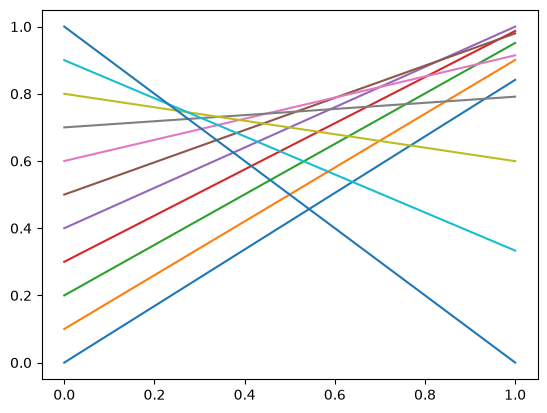

In [ ]:
import matplotlib.pyplot as plt
plt.plot(xx, np.sin(np.pi**xx))